<a href="https://colab.research.google.com/github/computacao-aplicada/lab01-eda-RafaeladaCunha/blob/main/Aula18_03_2026_winequality_uci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color:#1E3A5F; padding:30px 40px; border-radius:10px; margin-bottom:20px">
  <h1 style="color:#FFFFFF; font-family:Trebuchet MS; margin:0 0 8px 0;">Encontro 04 — Primeiros Classificadores</h1>
  <p style="color:#8FB8D8; font-size:14px; margin:0;">INAR230007 · Inteligência Artificial: Aprendizado de Máquinas · Aula Prática</p>
  <hr style="border-color:#0D9488; margin:16px 0 12px 0;">
  <p style="color:#E2EBF5; font-size:13px; margin:0;"><b>O que faremos hoje:</b> Treinar os nossos primeiros classificadores (KNN e Árvore de Decisão), separar dados em treino e teste, gerar uma Matriz de Confusão e ver com os próprios olhos a diferença entre erro de treino e erro de teste.</p>
</div>

## Roteiro da aula

| Etapa | O que faremos |
|-------|---------------|
| **0** | Instalação e importação das bibliotecas |
| **1** | Carregamento e exploração do dataset |
| **2** | Separação treino / teste |
| **3** | Primeiro classificador: K-Nearest Neighbors (KNN) |
| **4** | Segundo classificador: Árvore de Decisão |
| **5** | Matriz de Confusão |
| **6** | Erro de treino vs. erro de teste — vendo o overfitting |
| **7** | Desafio final |

---
## Etapa 0 · Importando as bibliotecas

Antes de qualquer coisa, precisamos importar as ferramentas que vamos usar. Na prática de Machine Learning, quase sempre usamos o mesmo conjunto de bibliotecas:

- `numpy` e `pandas` → manipulação de dados
- `matplotlib` e `seaborn` → visualizações
- `scikit-learn` → os algoritmos de ML

In [2]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualizações
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Dataset de exemplo
# from sklearn.datasets import load_iris

# Separação treino/teste
from sklearn.model_selection import train_test_split

# Classificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


---
## Etapa 1 · Conhecendo o dataset

Vamos usar o **Iris Dataset** — um dos datasets mais clássicos de ML, presente em praticamente todo curso introdutório. Ele foi publicado pelo estatístico Ronald Fisher em 1936.

### O problema
Dadas as medições de uma flor de íris, classificar a qual das **3 espécies** ela pertence:

| Espécie | Classe |
|---------|--------|
| *Iris setosa* | 0 |
| *Iris versicolor* | 1 |
| *Iris virginica* | 2 |

### As features (atributos de entrada)
Cada flor é descrita por **4 medições** em centímetros:
- Comprimento da sépala
- Largura da sépala
- Comprimento da pétala
- Largura da pétala

In [3]:
# Carregando o dataset
winequality_dataset_red = pd.read_csv(
    '/content/winequality-red.csv',
    sep=';'
)

winequality_dataset_white = pd.read_csv(
    '/content/winequality-white.csv',
    sep=';'
)

winequality_dataset_red['type'] = 'red'
winequality_dataset_white['type'] = 'white'

df = pd.concat([winequality_dataset_red, winequality_dataset_white], ignore_index=True)


df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


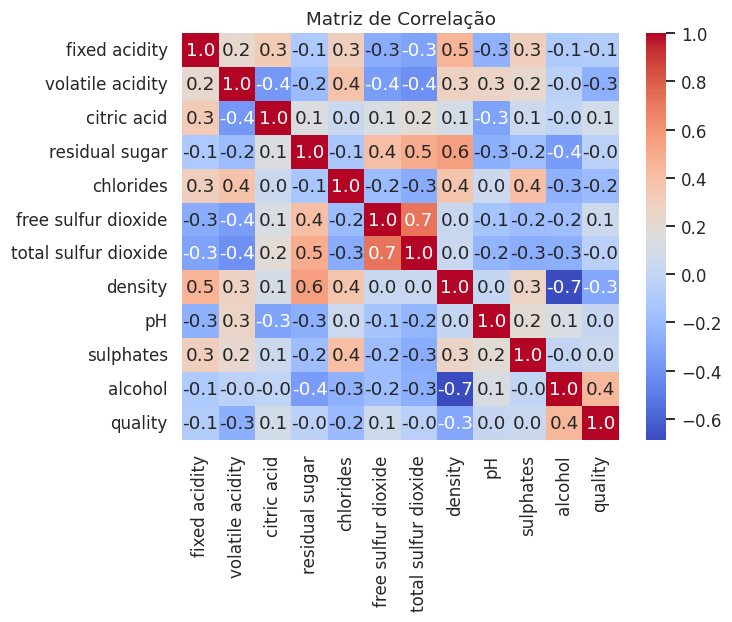

In [12]:
relacao= df.corr(numeric_only=True)
sns.heatmap(relacao, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Matriz de Correlação')

plt.show()

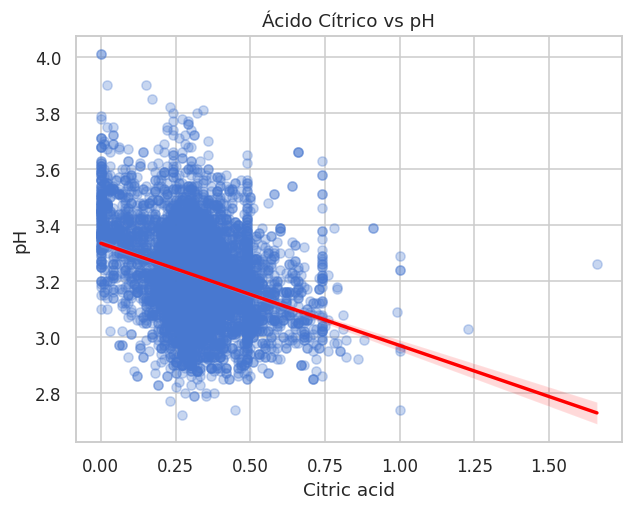

In [4]:
#1º Afirmação quando a acidez citrica for maior, menor será o ph

sns.regplot(
    data=df,
    x='citric acid',
    y='pH',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title('Ácido Cítrico vs pH')
plt.xlabel('Citric acid')
plt.ylabel('pH')

plt.show()

**Interpretação**

O gráfico de regressão entre citric acid e pH apresenta tendência negativa. Além disso, a matriz de correlação mostrou correlação de -0.3 entre as variáveis. Isso indica que o aumento da acidez cítrica está associado à diminuição do pH, tornando o vinho mais ácido.

**## 2º Segunda afirmação:**

 Vinhos com maior acidez volátil tendem a apresentar maiores níveis de cloretos.

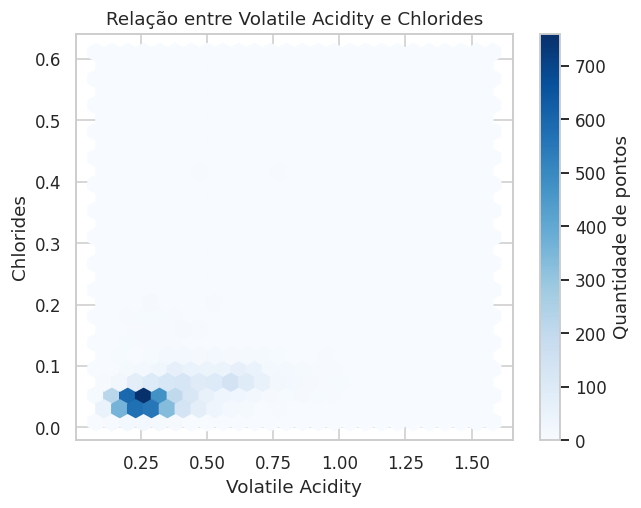

In [9]:
plt.hexbin(
    df['volatile acidity'],
    df['chlorides'],
    gridsize=25,
    cmap='Blues'
)

plt.xlabel('Volatile Acidity')
plt.ylabel('cloretos')
plt.title('Relação entre Volatile Acidity e Chlorides')

plt.colorbar(label='Quantidade de pontos')

plt.show()

## **Interpretação:**
O gráfico entre volatile acidity e chlorides apresenta uma tendência positiva, indicando que ambas as variáveis aumentam em conjunto. Além disso, a matriz de correlação revelou uma correlação positiva de 0.4 entre as variáveis. Isto indica que os vinhos com maior acidez volátil tendem também a possuir maior concentração de cloretos

## **3º Afirmação**

Os vinhos com maior acidez fixa tendem a apresentar maior densidade.

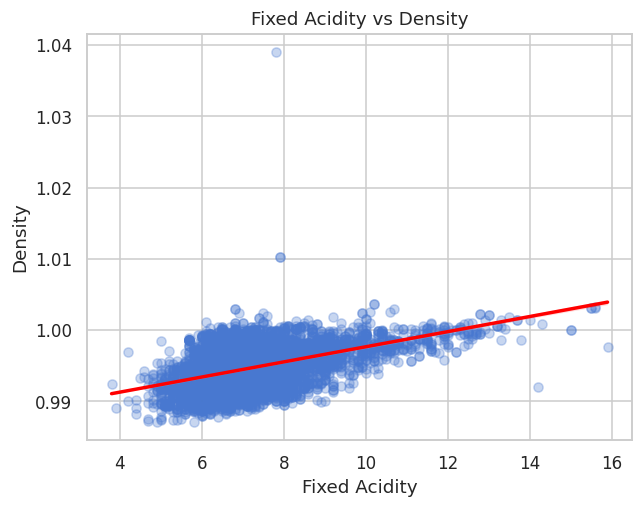

In [11]:
sns.regplot(
    data=df,
    x='fixed acidity',
    y='density',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title('Fixed Acidity vs Density')
plt.xlabel('Fixed Acidity')
plt.ylabel('Density')

plt.show()

O gráfico entre fixed acidity e density apresenta uma tendência positiva, indicando que ambas as variáveis aumentam.E também a matriz de correlação revelou uma correlação positiva de 0.5 entre as variáveis. Mostra que o aumento da acidez fixa está associado ao aumento da densidade do vinho, sugerindo uma relação moderada entre estas características químicas.

In [14]:

df_model = df.copy()

df_model["good_quality"] = (df_model["quality"] >= 7).astype(int)

X = df_model.drop(columns=["quality", "quality_group", "good_quality"])
y = df_model["good_quality"]

X = pd.get_dummies(X, columns=["type"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.25,
random_state=49,
stratify=y
)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Acurácia baseline:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

KeyError: "['quality_group'] not found in axis"

In [15]:
print(df_model.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type', 'good_quality'],
      dtype='object')


## Pré-processamento

Que é limpar a nossa base de dados! Como assim???

Removendo ou tratando os valores NaN, vazio, None e etc...

In [ ]:
# Separando features (X) e target (y)
# Separando features (X) e target (y)
#O dataset foi separado entre variáveis explicativas (features) e variável alvo (target).
#As features representam propriedades físico-químicas dos vinhos,
#enquanto o target quality representa a nota de qualidade do vinho.

X = winequality_dataset.drop(columns=['quality']).round(2)
y = winequality_dataset['quality']


print(f"X (features): {X.shape} → {X.shape[0]} amostras, {X.shape[1]} features cada")
print(f"y (target):   {y.shape} → {y.shape[0]} rótulos")

In [ ]:
# Separando em treino (80%) e teste (20%)
# random_state=42 garante que você e eu teremos os mesmos resultados (reprodutibilidade)
# stratify=y garante que a proporção das classes seja mantida nos dois conjuntos

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.33,    # 20% para teste
    random_state=42,  # semente aleatória — garante reprodutibilidade
    stratify=y       # mantém a proporção das classes
)

print(f"Treino:  {X_treino.shape[0]} amostras")
print(f"Teste:   {X_teste.shape[0]} amostras")
print()
print("Distribuição no treino:", dict(zip(*np.unique(y_treino, return_counts=True))))
print("Distribuição no teste: ", dict(zip(*np.unique(y_teste,  return_counts=True))))

<div style="background-color:#EFF6FF; border-left:4px solid #2563EB; padding:12px 16px; border-radius:4px;">

**💡 Ponto de atenção:** O parâmetro `stratify=y` é importante! Sem ele, por pura sorte, o conjunto de teste poderia acabar com poucos (ou nenhum) exemplos de uma das classes. Com ele, garantimos que a proporção de cada espécie é preservada.

**Regra de ouro:** A partir daqui, o conjunto de teste (`X_teste`, `y_teste`) **não deve ser usado** para nada além da avaliação final. Ele simula dados do mundo real que o modelo nunca viu.
</div>

---
## Etapa 3 · Primeiro Classificador: KNN

### Como funciona o K-Nearest Neighbors?

A ideia é simples: para classificar um novo ponto, olhe para os **K vizinhos mais próximos** no espaço de features e tome a **classe mais comum** entre eles.

```
Ponto novo: [5.1, 3.5, 1.4, 0.2]

Com K=3, encontra os 3 vizinhos mais próximos:
  → Vizinho 1: setosa
  → Vizinho 2: setosa
  → Vizinho 3: versicolor

Decisão: setosa (maioria vence)
```

**Parâmetro principal:** `n_neighbors` (= K) — quantos vizinhos considerar.
- K pequeno → modelo mais complexo, maior risco de overfitting
- K grande → modelo mais simples, maior risco de underfitting

In [ ]:
# Criando e treinando o modelo KNN com K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_treino, y_treino)  # <-- aqui o modelo "aprende" com os dados de treino

print("✅ Modelo KNN treinado!")

In [ ]:
# Fazendo previsões
y_pred_knn = knn.predict(X_teste)  # aplica o modelo nos dados de TESTE

# Comparando as primeiras 15 previsões com os valores reais
# nomes = penguins_df.species.unique()
# print(f"{'Real':<20} {'Previsto':<20} {'Acerto?'}")
# print("-" * 50)
# print
# for real, prev in zip(y_teste[:15], y_pred_knn[:15]):
#     acerto = "✅" if real == prev else "❌"
#     print(f"{nomes[real]:<20} {nomes[prev]:<20} {acerto}")

In [ ]:
# Calculando a acurácia
acuracia_knn_treino = accuracy_score(y_treino, knn.predict(X_treino))
acuracia_knn_teste  = accuracy_score(y_teste,  y_pred_knn)

print(f"KNN (K=5)")
print(f"  Acurácia no TREINO: {acuracia_knn_treino:.2%}")
print(f"  Acurácia no TESTE:  {acuracia_knn_teste:.2%}")

### 🤔 Pare e reflita

A diferença entre a acurácia no treino e no teste é o nosso primeiro sinal de **overfitting** (ou da falta dele). Se as duas fossem iguais e muito altas, seria ótimo. Se o teste fosse muito pior que o treino, teríamos overfitting.

Vamos explorar isso mais na Etapa 6.

---
## Etapa 4 · Segundo Classificador: Árvore de Decisão

### Como funciona?

A Árvore de Decisão aprende uma série de **perguntas sobre as features** que levam à classificação correta. Por exemplo:

```
petal length <= 2.45?
├── Sim → Setosa
└── Não → petal width <= 1.75?
           ├── Sim → Versicolor
           └── Não → Virginica
```

**Parâmetro principal:** `max_depth` — profundidade máxima da árvore.
- Sem limite → árvore cresce até separar todos os exemplos de treino (overfitting!)
- Muito pequena → árvore simples demais (underfitting)

Vamos começar com `max_depth=3`.

In [ ]:
# Criando e treinando a Árvore de Decisão
arvore = DecisionTreeClassifier(max_depth=3, random_state=42)
arvore.fit(X_treino, y_treino)

print("✅ Árvore de Decisão treinada!")

# Avaliando
y_pred_arvore = arvore.predict(X_teste)

acuracia_arvore_treino = accuracy_score(y_treino, arvore.predict(X_treino))
acuracia_arvore_teste  = accuracy_score(y_teste,  y_pred_arvore)

print(f"\nÁrvore de Decisão (max_depth=3)")
print(f"  Acurácia no TREINO: {acuracia_arvore_treino:.2%}")
print(f"  Acurácia no TESTE:  {acuracia_arvore_teste:.2%}")

In [ ]:
# Visualizando a árvore — esse é um dos grandes pontos fortes das árvores de decisão:
# elas são interpretáveis!

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    arvore,
    feature_names=quality.citric,
    class_names=quality.citric,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=False
)
plt.title('Árvore de Decisão (max_depth=3)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**Leia a árvore de cima para baixo:**
- Cada **nó interno** faz uma pergunta: `feature <= valor?`
- Ir para a **esquerda** significa "Sim"
- Ir para a **direita** significa "Não"
- Cada **folha** (nó final) contém a classe predita e o número de amostras de treino que caíram ali

**Qual feature é a mais importante?** Aquela na raiz da árvore — o algoritmo escolheu ela como o melhor ponto de partida para separar as classes.

In [ ]:
# Importância das features
importancias = pd.Series(arvore.feature_importances_, index= quality-red)
importancias = importancias.sort_values(ascending=True)

cores_barras = ['#E2EBF5' if v < 0.3 else '#0D9488' for v in importancias]

fig, ax = plt.subplots(figsize=(8, 3.5))
importancias.plot.barh(ax=ax, color=cores_barras)
ax.set_xlabel('Importância relativa')
ax.set_title('Importância das Features — Árvore de Decisão', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nImportâncias:")
for feat, imp in importancias.sort_values(ascending=False).items():
    print(f"  {feat:<30} {imp:.3f}")

---
## Etapa 5 · Matriz de Confusão

A acurácia nos diz **quantos** acertamos, mas não **onde** erramos. A **Matriz de Confusão** resolve isso.

Cada linha representa a classe **real**; cada coluna representa a classe **prevista**.
Os valores na diagonal principal são os **acertos**. Fora da diagonal são os **erros**.

```
                   Previsto
              Set  Ver  Vir
Real  Set  [ 10    0    0 ]   ← todos os setosa foram classificados corretamente
      Ver  [  0    9    1 ]   ← 1 versicolor foi classificado como virginica
      Vir  [  0    0   10 ]   ← todos os virginica foram classificados corretamente
```

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# KNN
cm_knn = confusion_matrix(y_teste, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(cm_knn, display_labels=quality.target_names)
disp_knn.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'KNN (K=5)\nAcurácia no teste: {acuracia_knn_teste:.2%}',
                  fontweight='bold')

# Árvore de Decisão
cm_arvore = confusion_matrix(y_teste, y_pred_arvore)
disp_arvore = ConfusionMatrixDisplay(cm_arvore, display_labels=quality.target_names)
disp_arvore.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Árvore de Decisão (max_depth=3)\nAcurácia no teste: {acuracia_arvore_teste:.2%}',
                  fontweight='bold')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Relatório completo com precisão, recall e F1
# (Veremos em detalhe no Encontro 05 — hoje apenas observe os números)

print("=" * 55)
print("RELATÓRIO — KNN")
print("=" * 55)
print(classification_report(y_teste, y_pred_knn, target_names=quality.target_names))

print("=" * 55)
print("RELATÓRIO — ÁRVORE DE DECISÃO")
print("=" * 55)
print(classification_report(y_teste, y_pred_arvore, target_names=quality.target_names))

**O que observar:**
- `precision` — dos que o modelo disse que eram setosa, quantos eram de fato setosa?
- `recall` — dos que eram setosa, quantos o modelo encontrou?
- `f1-score` — uma média harmônica de precision e recall
- `support` — quantas amostras reais existem de cada classe no conjunto de teste

Vamos aprofundar essas métricas no **Encontro 05**.

---
## Etapa 6 · Erro de Treino vs. Erro de Teste — vendo o overfitting

Agora vamos fazer o experimento mais importante da aula: ver como a **complexidade do modelo** afeta o desempenho no treino e no teste.

### Experimento A — KNN: variando K

Vamos testar KNN com diferentes valores de K e observar o que acontece com o erro de treino e teste.

In [ ]:
ks = range(1, 31)
erros_treino_knn = []
erros_teste_knn  = []

for k in ks:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_treino, y_treino)
    erros_treino_knn.append(1 - accuracy_score(y_treino, modelo.predict(X_treino)))
    erros_teste_knn.append( 1 - accuracy_score(y_teste,  modelo.predict(X_teste)))

# Plotando
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(ks, erros_treino_knn, 'o-', color='#0D9488', linewidth=2, markersize=5, label='Erro de Treino')
ax.plot(ks, erros_teste_knn,  's-', color='#E05252', linewidth=2, markersize=5, label='Erro de Teste')

ax.axvspan(1, 3, alpha=0.08, color='#E05252', label='Zona de Overfitting')
ax.axvspan(20, 30, alpha=0.08, color='#16A34A', label='Zona de Underfitting')

ax.set_xlabel('Valor de K (número de vizinhos)', fontsize=11)
ax.set_ylabel('Erro (1 - Acurácia)', fontsize=11)
ax.set_title('KNN — Erro de Treino e Teste conforme K varia', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(list(ks))

# Invertendo o eixo X para que K pequeno (mais complexo) fique à esquerda
ax.invert_xaxis()
ax.text(29.5, max(erros_teste_knn)*0.85, '← Mais complexo', fontsize=9, color='#E05252')
ax.text(1.5,  max(erros_teste_knn)*0.85, 'Mais simples →',  fontsize=9, color='#16A34A')

plt.tight_layout()
plt.show()

**O que você vê no gráfico?**
- **K=1** (extrema esquerda): o erro de treino é **0** (o modelo memoriza tudo!), mas o erro de teste é alto → **overfitting**
- **K muito alto** (extrema direita): o erro de treino sobe → **underfitting**
- Existe um **ponto ideal** em algum K intermediário — menor erro de teste

Isso é exatamente a **curva viés-variância** que vimos na aula teórica!

In [ ]:
# Qual K teve o menor erro de teste?
melhor_k = list(ks)[np.argmin(erros_teste_knn)]
print(f"Melhor K encontrado: {melhor_k}")
print(f"  Erro de treino: {erros_treino_knn[melhor_k-1]:.2%}")
print(f"  Erro de teste:  {erros_teste_knn[melhor_k-1]:.2%}")

### Experimento B — Árvore de Decisão: variando a profundidade

Agora fazemos o mesmo experimento com a Árvore de Decisão, variando o `max_depth`.

In [ ]:
profundidades = range(1, 16)
erros_treino_tree = []
erros_teste_tree  = []

for prof in profundidades:
    modelo = DecisionTreeClassifier(max_depth=prof, random_state=42)
    modelo.fit(X_treino, y_treino)
    erros_treino_tree.append(1 - accuracy_score(y_treino, modelo.predict(X_treino)))
    erros_teste_tree.append( 1 - accuracy_score(y_teste,  modelo.predict(X_teste)))

# Plotando
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(profundidades, erros_treino_tree, 'o-', color='#0D9488', linewidth=2, markersize=6, label='Erro de Treino')
ax.plot(profundidades, erros_teste_tree,  's-', color='#E05252', linewidth=2, markersize=6, label='Erro de Teste')

ax.axvspan(7, 15, alpha=0.08, color='#E05252', label='Zona de Overfitting')

ax.set_xlabel('Profundidade máxima da árvore', fontsize=11)
ax.set_ylabel('Erro (1 - Acurácia)', fontsize=11)
ax.set_title('Árvore de Decisão — Erro de Treino e Teste conforme profundidade varia',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_xticks(list(profundidades))

plt.tight_layout()
plt.show()

**O que você vê?**
- Com profundidade maior, o erro de treino cai para **0** — a árvore aprende a resposta exata de cada exemplo
- Mas o erro de teste **não melhora** (e pode piorar) com profundidade excessiva
- **Profundidades muito grandes = overfitting**

In [ ]:
# Resumo comparativo de todos os modelos testados
print("Resumo comparativo")
print("="*55)
print(f"{'Modelo':<35} {'Treino':>8} {'Teste':>8}")
print("-"*55)
print(f"{'KNN (K=5)':<35} {acuracia_knn_treino:>8.2%} {acuracia_knn_teste:>8.2%}")
print(f"{'Árvore de Decisão (max_depth=3)':<35} {acuracia_arvore_treino:>8.2%} {acuracia_arvore_teste:>8.2%}")

# Melhor de cada experimento
melhor_prof = list(profundidades)[np.argmin(erros_teste_tree)]
melhor_arvore = DecisionTreeClassifier(max_depth=melhor_prof, random_state=42)
melhor_arvore.fit(X_treino, y_treino)
ac_mt = accuracy_score(y_treino, melhor_arvore.predict(X_treino))
ac_me = accuracy_score(y_teste,  melhor_arvore.predict(X_teste))
print(f"{'Árvore de Decisão (melhor depth)':<35} {ac_mt:>8.2%} {ac_me:>8.2%}   ← depth={melhor_prof}")

melhor_knn_model = KNeighborsClassifier(n_neighbors=melhor_k)
melhor_knn_model.fit(X_treino, y_treino)
ac_kt = accuracy_score(y_treino, melhor_knn_model.predict(X_treino))
ac_ke = accuracy_score(y_teste,  melhor_knn_model.predict(X_teste))
print(f"{'KNN (melhor K)':<35} {ac_kt:>8.2%} {ac_ke:>8.2%}   ← K={melhor_k}")

print("="*55)
print("\n⚠️  Lembre-se: o conjunto de teste foi usado aqui para")
print("   comparar modelos — na prática, isso é feito com")
print("   um conjunto de VALIDAÇÃO. Veremos isso no Encontro 05.")

---
## Etapa 7 · Desafio Final

Agora é a sua vez de explorar! Pegue o dataset dos [pinguins](https://archive.ics.uci.edu/dataset/690/palmer+penguins-3), reexecute as etapas e elabore um mini relatório com seus achados.
